# TP3 : Clustering de documents textuels avec K-means

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import sklearn

import warnings
warnings.filterwarnings('ignore')

## 1. Prétraitement du texte

### 1.1 Chargement des données

In [4]:
df = pd.read_csv('people_wiki.csv')

print(f"Nombre de documents : {len(df)}")
print(f"Colonnes : {df.columns.tolist()}")
df.head()

Nombre de documents : 59071
Colonnes : ['URI', 'name', 'text']


,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...


In [5]:
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

df = df.dropna(subset=['text'])
print(f"\nNombre de documents apres nettoyage : {len(df)}")

Valeurs manquantes par colonne :
URI     0
name    0
text    0
dtype: int64

Nombre de documents apres nettoyage : 59071


In [6]:
print("Exemple de texte brut :")
print(f"Nom : {df.iloc[0]['name']}")
print(f"Texte : {df.iloc[0]['text'][:500]}...")

Exemple de texte brut :
Nom : Digby Morrell
Texte : digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his early senior football for west perth his 44game senior career for the falcons spanned 19982000 and he was the clubs leading goalkicker in 2000 at the age of 21 morrell was recruited to the australian football league by the kangaroos football club with its third round selection in the 2001 afl rookie dra...


### 1.2 Nettoyage du texte

On applique les traitements suivants :
- Mise en minuscules
- Suppression de la ponctuation
- Suppression des stopwords anglais

In [7]:
# stopwords anglais
STOPWORDS = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your',
    'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she',
    'her', 'hers', 'herself', 'it', 'its', 'itself', 'they', 'them', 'their',
    'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that',
    'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an',
    'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of',
    'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through',
    'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down',
    'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then',
    'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'each',
    'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only',
    'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just',
    'don', 'should', 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren',
    'couldn', 'didn', 'doesn', 'hadn', 'hasn', 'haven', 'isn', 'ma', 'mightn',
    'mustn', 'needn', 'shan', 'shouldn', 'wasn', 'weren', 'won', 'wouldn',
    'also', 'would', 'could'
}

def clean_text(text):
    """
    Nettoie le texte :
    - Mise en minuscules
    - Suppression de la ponctuation
    - Suppression des stopwords
    """
    # Mise en minuscules
    text = text.lower()
    
    # Suppression de la ponctuation
    text = re.sub(f'[{re.escape(string.punctuation)}]', ' ', text)
    
    # Suppression des chiffres isolés
    text = re.sub(r'\b\d+\b', '', text)
    
    # Tokenisation et suppression des stopwords
    words = text.split()
    words = [w for w in words if w not in STOPWORDS and len(w) > 1]
    
    return ' '.join(words)

In [8]:
# Nettoyage du texte
df['text_clean'] = df['text'].apply(clean_text)

In [9]:
# Comparaison avant/après nettoyage
idx = 0
print("AVANT nettoyage :")
print(df.iloc[idx]['text'][:300])
print("\n" + "="*50 + "\n")
print("APRÈS nettoyage :")
print(df.iloc[idx]['text_clean'][:300])

AVANT nettoyage :
digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his early senior football for west perth his 44game senior career for the falcons spanned 19982000 and he wa


APRÈS nettoyage :
digby morrell born october former australian rules footballer played kangaroos carlton australian football league aflfrom western australia morrell played early senior football west perth 44game senior career falcons spanned clubs leading goalkicker age morrell recruited australian football league k


## 2. Représentation vectorielle (TF-IDF)

On transforme les documents en vecteurs numériques.

In [10]:
# Création du vectoriseur TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.7,
    ngram_range=(1, 1)
)

# Transformation des documents
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_clean'])
print(f"Matrice TF-IDF : {tfidf_matrix.shape}")
print(f"  - {tfidf_matrix.shape[0]} documents")
print(f"  - {tfidf_matrix.shape[1]} termes dans le vocabulaire")

Matrice TF-IDF : (59071, 5000)
  - 59071 documents
  - 5000 termes dans le vocabulaire


In [11]:
# Récupération du vocabulaire
vocabulary = tfidf_vectorizer.get_feature_names_out()
print(f"Taille du vocabulaire : {len(vocabulary)}")
print(f"\nExemples de mots du vocabulaire : {vocabulary[:20].tolist()}")

Taille du vocabulaire : 5000

Exemples de mots du vocabulaire : ['10th', '11th', '12th', '13th', '14th', '15th', '16th', '17th', '18th', '1950s', '1960s', '1970s', '1980s', '1990s', '19th', '1st', '2000s', '20th', '21st', '25th']


In [12]:
# Vérification de la matrice (sparse)
print(f"Type de matrice : {type(tfidf_matrix)}")
print(f"Densité de la matrice : {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]) * 100:.2f}%")

Type de matrice : <class 'scipy.sparse._csr.csr_matrix'>
Densité de la matrice : 1.90%


## 3. Application de l'algorithme K-means

### 3.1 Comparaison des méthodes d'initialisation

On compare deux méthodes d'initialisation des centroïdes :
- **random** : initialisation aléatoire
- **k-means++** : initialisation intelligente qui favorise des centroïdes éloignés

In [ ]:
def run_kmeans(X, n_clusters, init_method, random_state=42, n_init=10):
    """ Exécute K-means et retourne le modèle avec les métriques. """
    kmeans = KMeans(
        n_clusters=n_clusters,
        init=init_method,
        random_state=random_state,
        n_init=n_init,
        max_iter=300
    )
    kmeans.fit(X)
    return kmeans

In [14]:
# Comparaison random vs k-means++ avec k=10
k = 10

print(f"Clustering avec k={k} clusters\n")
print("="*50)

# Initialisation random
print("Méthode : RANDOM")
kmeans_random = run_kmeans(tfidf_matrix, k, 'random', random_state=42)
print(f"  Inertie (hétérogénéité) : {kmeans_random.inertia_:.2f}")
print(f"  Nombre d'itérations : {kmeans_random.n_iter_}")

print()

# Initialisation k-means++
print("Méthode : K-MEANS++")
kmeans_pp = run_kmeans(tfidf_matrix, k, 'k-means++', random_state=42)
print(f"  Inertie (hétérogénéité) : {kmeans_pp.inertia_:.2f}")
print(f"  Nombre d'itérations : {kmeans_pp.n_iter_}")

print("\n" + "="*50)
print(f"\nDifférence d'inertie : {kmeans_random.inertia_ - kmeans_pp.inertia_:.2f}")
print(f"K-means++ est {'meilleur' if kmeans_pp.inertia_ < kmeans_random.inertia_ else 'moins bon'} (inertie plus faible = meilleur)")

Clustering avec k=10 clusters

Méthode : RANDOM
  Inertie (hétérogénéité) : 54558.27
  Nombre d'itérations : 26

Méthode : K-MEANS++
  Inertie (hétérogénéité) : 54535.70
  Nombre d'itérations : 39


Différence d'inertie : 22.56
K-means++ est meilleur (inertie plus faible = meilleur)


### 3.2 Influence de la graine aléatoire (random_state)

In [15]:
# Test avec différentes graines aléatoires
random_states = [0, 42, 123, 456, 789]
results_random = []
results_pp = []

print("Influence de random_state sur l'inertie (k=10)\n")
print(f"{'random_state':<15} {'Random':<20} {'K-means++':<20}")
print("-" * 55)

for rs in random_states:
    km_random = run_kmeans(tfidf_matrix, 10, 'random', random_state=rs, n_init=1)
    km_pp = run_kmeans(tfidf_matrix, 10, 'k-means++', random_state=rs, n_init=1)
    
    results_random.append(km_random.inertia_)
    results_pp.append(km_pp.inertia_)
    
    print(f"{rs:<15} {km_random.inertia_:<20.2f} {km_pp.inertia_:<20.2f}")

print("-" * 55)
print(f"{'Moyenne':<15} {np.mean(results_random):<20.2f} {np.mean(results_pp):<20.2f}")
print(f"{'Écart-type':<15} {np.std(results_random):<20.2f} {np.std(results_pp):<20.2f}")

Influence de random_state sur l'inertie (k=10)

random_state    Random               K-means++           
-------------------------------------------------------
0               54646.96             54644.16            
42              54593.69             54596.86            
123             54687.17             54656.98            
456             54714.97             54560.80            
789             54646.96             54563.32            
-------------------------------------------------------
Moyenne         54657.95             54604.42            
Écart-type      41.17                39.97               


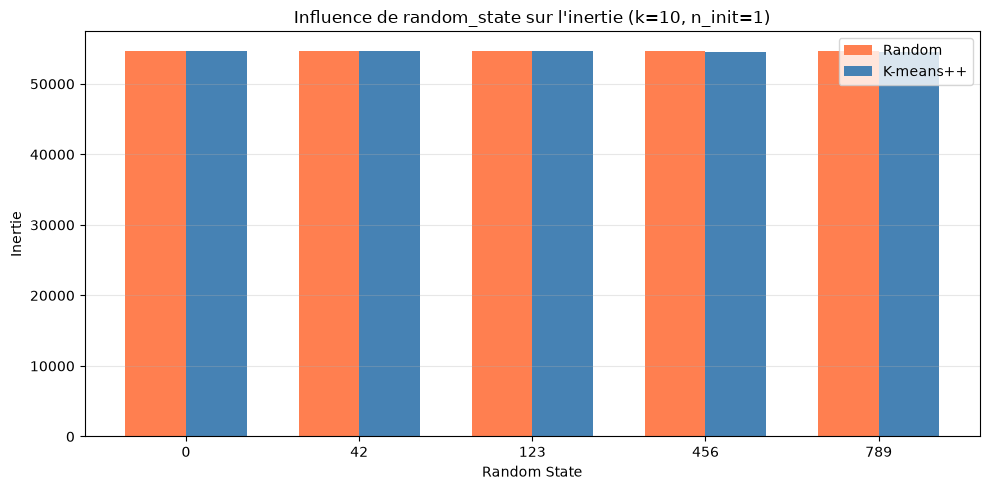

In [16]:
# Visualisation de la variabilité
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(random_states))
width = 0.35

bars1 = ax.bar(x - width/2, results_random, width, label='Random', color='coral')
bars2 = ax.bar(x + width/2, results_pp, width, label='K-means++', color='steelblue')

ax.set_xlabel('Random State')
ax.set_ylabel('Inertie')
ax.set_title("Influence de random_state sur l'inertie (k=10, n_init=1)")
ax.set_xticks(x)
ax.set_xticklabels(random_states)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Choix du nombre de clusters

On étudie la variation de l'hétérogénéité (inertie) pour différentes valeurs de k.

In [18]:
# Valeurs de k à tester
k_values = [2, 10, 25, 50, 100]
inertias = []

for k in k_values:
    print(f"k = {k}...", end=" ")
    kmeans = run_kmeans(tfidf_matrix, k, 'k-means++', random_state=42)
    inertias.append(kmeans.inertia_)
    print(f"Inertie = {kmeans.inertia_:.2f}")

k = 2... Inertie = 56634.37
k = 10... Inertie = 54535.70
k = 25... Inertie = 52921.88
k = 50... Inertie = 51495.47
k = 100... Inertie = 49928.32


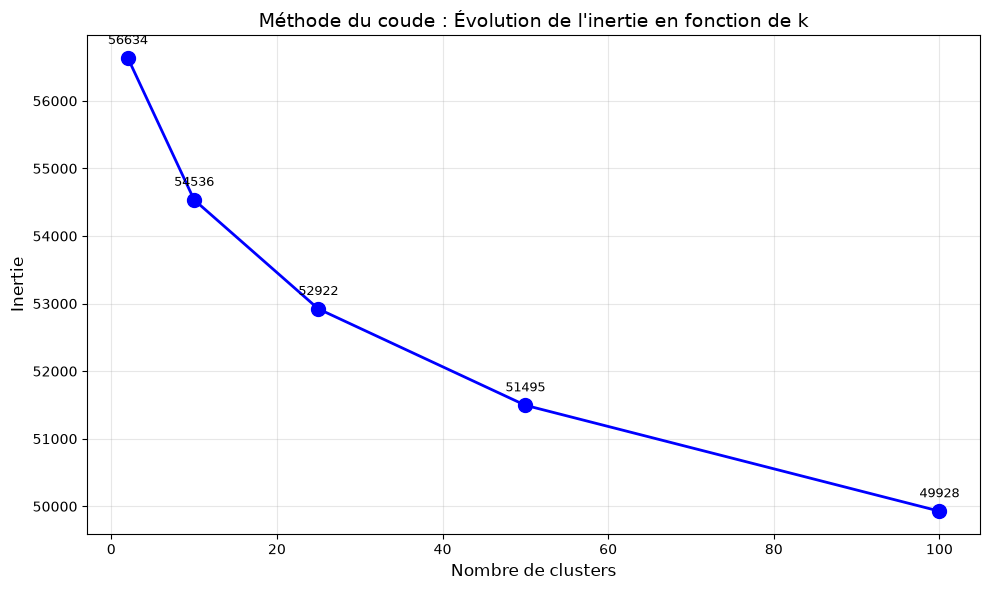

In [19]:
# Graphique de l'evolution de l'inertie
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(k_values, inertias, 'bo-', linewidth=2, markersize=10)
ax.set_xlabel('Nombre de clusters', fontsize=12)
ax.set_ylabel('Inertie', fontsize=12)
ax.set_title("Méthode du coude : Évolution de l'inertie en fonction de k", fontsize=14)
ax.grid(True, alpha=0.3)

# Annotation des points
for i, (k, inertia) in enumerate(zip(k_values, inertias)):
    ax.annotate(f'{inertia:.0f}', (k, inertia), textcoords="offset points", 
                xytext=(0, 10), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Calcul de la reduction relative d'inertie
print("Réduction relative de l'inertie entre valeurs successives de k :\n")
for i in range(1, len(k_values)):
    reduction = (inertias[i-1] - inertias[i]) / inertias[i-1] * 100
    print(f"k={k_values[i-1]} -> k={k_values[i]} : réduction de {reduction:.1f}%")

Réduction relative de l'inertie entre valeurs successives de k :

k=2 -> k=10 : réduction de 3.7%
k=10 -> k=25 : réduction de 3.0%
k=25 -> k=50 : réduction de 2.7%
k=50 -> k=100 : réduction de 3.0%


**Analyse** : 
- L'inertie diminue naturellement quand k augmente (plus de clusters = moins de variance intra-cluster)
- On cherche un "coude" où l'amélioration marginale devient faible
- Un bon compromis semble être autour de **k=10 à 25**, où la courbe commence à s'aplatir significativement

## 5. Visualisation des clusters

On analyse les clusters obtenus pour k=10.

In [21]:
# Modele final avec k=10
k_final = 10
kmeans_final = run_kmeans(tfidf_matrix, k_final, 'k-means++', random_state=42)

# Attribution des clusters aux documents
df['cluster'] = kmeans_final.labels_

# Distribution des clusters
print(f"Distribution des documents dans les {k_final} clusters :\n")
cluster_counts = df['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    print(f"  Cluster {cluster_id}: {count} documents ({count/len(df)*100:.1f}%)")

Distribution des documents dans les 10 clusters :

  Cluster 0: 8606 documents (14.6%)
  Cluster 1: 4226 documents (7.2%)
  Cluster 2: 1779 documents (3.0%)
  Cluster 3: 6143 documents (10.4%)
  Cluster 4: 6571 documents (11.1%)
  Cluster 5: 4794 documents (8.1%)
  Cluster 6: 16699 documents (28.3%)
  Cluster 7: 5621 documents (9.5%)
  Cluster 8: 2728 documents (4.6%)
  Cluster 9: 1904 documents (3.2%)


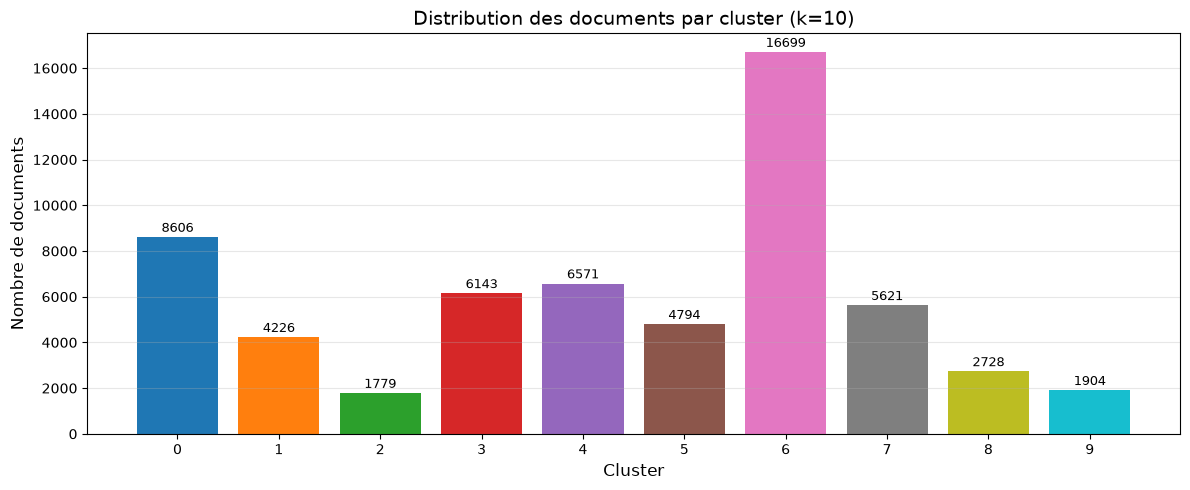

In [22]:
# Visualisation de la distribution
fig, ax = plt.subplots(figsize=(12, 5))

colors = plt.cm.tab10(np.linspace(0, 1, k_final))
bars = ax.bar(cluster_counts.index, cluster_counts.values, color=colors)

ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Nombre de documents', fontsize=12)
ax.set_title(f'Distribution des documents par cluster (k={k_final})', fontsize=14)
ax.set_xticks(range(k_final))
ax.grid(axis='y', alpha=0.3)

# Ajouter les valeurs sur les barres
for bar, count in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
            str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 5.1 Mots les plus représentatifs par cluster

In [23]:
def get_top_terms_per_cluster(kmeans_model, vectorizer, n_terms=10):
    """ Retourne les mots les plus représentatifs pour chaque cluster basé sur les poids TF-IDF des centroïdes. """
    terms = vectorizer.get_feature_names_out()
    centroids = kmeans_model.cluster_centers_
    
    top_terms = {}
    for i, centroid in enumerate(centroids):
        # Indices des termes avec les poids les plus élevés
        top_indices = centroid.argsort()[-n_terms:][::-1]
        top_terms[i] = [(terms[idx], centroid[idx]) for idx in top_indices]
    
    return top_terms

In [24]:
# Affichage des mots les plus représentatifs
top_terms = get_top_terms_per_cluster(kmeans_final, tfidf_vectorizer, n_terms=10)

print("Mots les plus représentatifs par cluster (k=10)\n")
print("="*70)

for cluster_id, terms in top_terms.items():
    n_docs = len(df[df['cluster'] == cluster_id])
    print(f"\nCluster {cluster_id} ({n_docs} documents):")
    terms_str = ", ".join([f"{term}" for term, weight in terms])
    print(f"  {terms_str}")

Mots les plus représentatifs par cluster (k=10)


Cluster 0 (8606 documents):
  university, research, professor, law, science, institute, president, served, international, school

Cluster 1 (4226 documents):
  world, championships, championship, team, tour, racing, olympics, race, champion, finished

Cluster 2 (1779 documents):
  league, baseball, major, season, games, runs, pitcher, played, minor, sox

Cluster 3 (6143 documents):
  party, election, minister, elected, member, served, state, politician, committee, government

Cluster 4 (6571 documents):
  season, football, played, league, team, coach, club, cup, player, games

Cluster 5 (4794 documents):
  film, theatre, films, television, series, role, actor, award, directed, best

Cluster 6 (16699 documents):
  book, new, published, first, university, radio, one, show, years, books

Cluster 7 (5621 documents):
  album, band, music, released, song, records, songs, albums, singer, rock

Cluster 8 (2728 documents):
  music, orchestra, op

### 5.2 Documents proches des centroïdes

In [26]:
def get_closest_documents(kmeans_model, tfidf_matrix, df, n_docs=3):
    """ Retourne les documents les plus proches de chaque centroïde. """
    closest_docs = {}
    
    for cluster_id in range(kmeans_model.n_clusters):
        # Indices des documents dans ce cluster
        cluster_mask = kmeans_model.labels_ == cluster_id
        cluster_indices = np.where(cluster_mask)[0]
        
        if len(cluster_indices) == 0:
            continue
        
        # Calcul des distances au centroïde
        centroid = kmeans_model.cluster_centers_[cluster_id]
        cluster_vectors = tfidf_matrix[cluster_indices]
        
        # Distance euclidienne
        distances = np.sqrt(((cluster_vectors.toarray() - centroid) ** 2).sum(axis=1))
        
        # Indices des documents les plus proches
        closest_indices = distances.argsort()[:n_docs]
        
        closest_docs[cluster_id] = [
            (cluster_indices[idx], df.iloc[cluster_indices[idx]]['name'], 
             df.iloc[cluster_indices[idx]]['text_clean'][:200])
            for idx in closest_indices
        ]
    
    return closest_docs

In [27]:
# Documents les plus proches des centroïdes
closest_docs = get_closest_documents(kmeans_final, tfidf_matrix, df, n_docs=3)

print("Documents les plus proches de chaque centroïde (k=10)\n")
print("="*80)

for cluster_id, docs in closest_docs.items():
    print(f"\n--- Cluster {cluster_id} ---")
    for idx, name, text in docs:
        print(f"\n  * {name}")
        print(f"    {text}...")

Documents les plus proches de chaque centroïde (k=10)


--- Cluster 0 ---

  * R. C. T. Lee
    lee lee chiatung chinese born shanghai china known richard lee received bsc degree department electrical engineering national taiwan university phd degree department electrical engineering computer sc...

  * I. William Zartman
    ira william zartman professor emeritus paul nitze school advanced international studies sais johns hopkins university earlier directed schools conflict management african studies programs continues te...

  * Erwin J. Haeberle
    erwin haeberle born march german social scientist sexologisthaeberle born march dortmund germany studied drama german english literature french literature university cologne university freiburg univer...

--- Cluster 1 ---

  * Ayelech Worku
    ayelech worku born june ethiopian longdistance runner known winning two world championships bronze medals metres born arsi zone oromia province region double olympic champion haile gebrselassiewo

## 6. Analyse comparative

### 6.1 Comparaison k=2 vs k=10

In [28]:
# Clustering avec k=2
kmeans_k2 = run_kmeans(tfidf_matrix, 2, 'k-means++', random_state=42)
df['cluster_k2'] = kmeans_k2.labels_

print("Comparaison k=2 vs k=10\n")
print("="*60)

print(f"\n{'Métrique':<30} {'k=2':<15} {'k=10':<15}")
print("-"*60)
print(f"{'Inertie':<30} {kmeans_k2.inertia_:<15.2f} {kmeans_final.inertia_:<15.2f}")
print(f"{'Nombre d iterations':<30} {kmeans_k2.n_iter_:<15} {kmeans_final.n_iter_:<15}")

Comparaison k=2 vs k=10


Métrique                       k=2             k=10           
------------------------------------------------------------
Inertie                        56634.37        54535.70       
Nombre d iterations            44              39             


In [29]:
# Mots représentatifs pour k=2
top_terms_k2 = get_top_terms_per_cluster(kmeans_k2, tfidf_vectorizer, n_terms=15)

print("\nMots les plus représentatifs pour k=2 :\n")
for cluster_id, terms in top_terms_k2.items():
    n_docs = len(df[df['cluster_k2'] == cluster_id])
    print(f"Cluster {cluster_id} ({n_docs} documents):")
    terms_str = ", ".join([f"{term}" for term, weight in terms])
    print(f"  {terms_str}\n")


Mots les plus représentatifs pour k=2 :

Cluster 0 (12103 documents):
  league, season, team, played, football, coach, games, club, player, cup, championship, world, career, first, professional

Cluster 1 (46968 documents):
  university, music, new, film, first, member, work, school, american, award, one, served, album, director, york



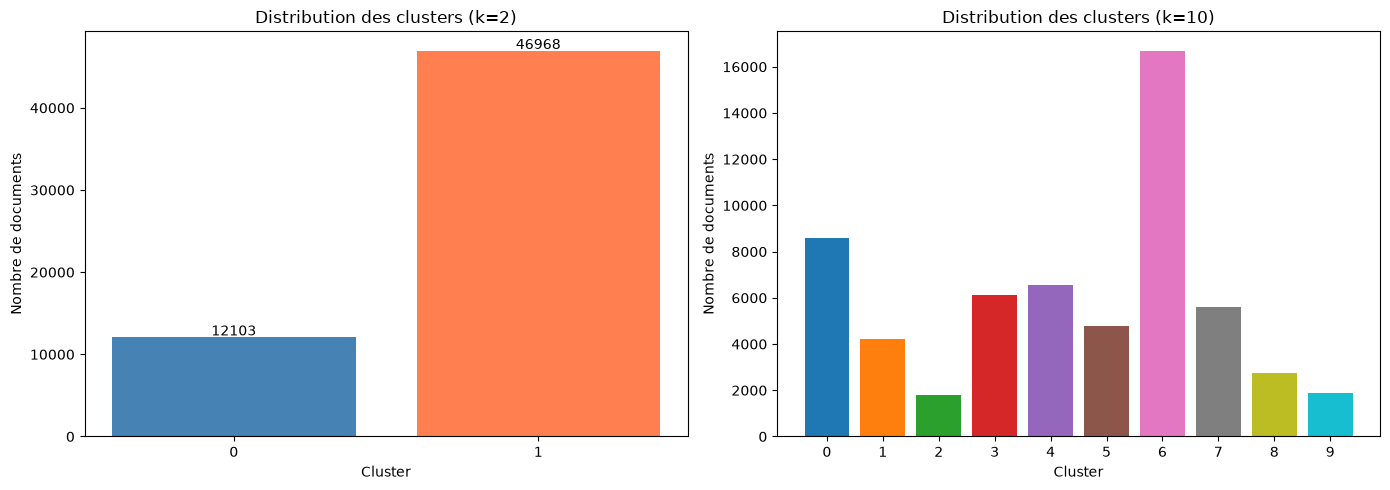

In [30]:
# Distribution comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# k=2
counts_k2 = df['cluster_k2'].value_counts().sort_index()
axes[0].bar(counts_k2.index, counts_k2.values, color=['steelblue', 'coral'])
axes[0].set_title('Distribution des clusters (k=2)', fontsize=12)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Nombre de documents')
axes[0].set_xticks([0, 1])
for i, v in enumerate(counts_k2.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontsize=10)

# k=10
counts_k10 = df['cluster'].value_counts().sort_index()
colors = plt.cm.tab10(np.linspace(0, 1, 10))
axes[1].bar(counts_k10.index, counts_k10.values, color=colors)
axes[1].set_title('Distribution des clusters (k=10)', fontsize=12)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Nombre de documents')
axes[1].set_xticks(range(10))

plt.tight_layout()
plt.show()

### 6.2 Discussion et conclusions

#### Pertinence des regroupements obtenus

**Pour k=2** :
- Les clusters sont tres generaux et regroupent des thematiques larges
- On observe souvent une division entre des domaines très distincts (ex: sport vs arts/sciences)
- La granularite est insuffisante pour identifier des themes precis

**Pour k=10** :
- Les clusters sont plus specialises et coherents thematiquement
- On peut identifier des groupes distincts (musiciens, sportifs, politiciens, scientifiques, etc.)
- La qualité des regroupements est meilleure pour l'interpretation

#### Effet de l'initialisation

- `K-means++` produit des resultats plus stables et generalement de meilleure qualite (inertie plus faible)
- L'initialisation `random` est plus sensible a la graine aleatoire et peut converger vers des optima locaux de moins bonne qualite
- L'ecart-type des resultats est significativement plus faible avec `K-means++`

#### Compromis entre nombre de clusters et qualité

- **Peu de clusters (k=2)** : 
  - Interpretation facile mais perte d'information
  - Clusters heterogenes (inertie elevee)
  
- **Beaucoup de clusters (k=100)** :
  - Inertie faible mais risque de sur-segmentation
  - Clusters potentiellement difficiles à interpréter
  
- **Compromis optimal (k=10-25)** :
  - Bon équilibre entre homogenéite des clusters et interpretabilite
  - La méthode du coude suggere que l'amelioration marginale diminue significativement après k=25

### 6.3 Résumé des résultats

In [32]:
# Tableau récapitulatif
print("\n" + "="*70)
print("RÉSUME DU TP : Clustering de documents textuels avec K-means")
print("="*70)

print(f"\n1. DONNEES")
print(f"   - Nombre de documents : {len(df)}")
print(f"   - Taille du vocabulaire TF-IDF : {len(vocabulary)} termes")

print(f"\n2. COMPARAISON DES INITIALISATIONS (k=10)")
print(f"   - Random : inertie moyenne = {np.mean(results_random):.2f} (ecart-type = {np.std(results_random):.2f})")
print(f"   - K-means++ : inertie moyenne = {np.mean(results_pp):.2f} (ecart-type = {np.std(results_pp):.2f})")
print(f"   -> K-means++ est plus stable et produit de meilleurs résultats")

print(f"\n3. CHOIX DU NOMBRE DE CLUSTERS")
print(f"   - Valeurs testees : {k_values}")
print(f"   - Inertie correspondante : {[f'{i:.0f}' for i in inertias]}")
print(f"   -> Recommandation : k=10 à 25 (bon compromis qualite/interpretabilite)")

print(f"\n4. CLUSTERING FINAL (k=10, K-means++)")
print(f"   - Inertie finale : {kmeans_final.inertia_:.2f}")
print(f"   - Distribution des clusters : min={cluster_counts.min()}, max={cluster_counts.max()}")

print("\n" + "="*70)


RÉSUME DU TP : Clustering de documents textuels avec K-means

1. DONNEES
   - Nombre de documents : 59071
   - Taille du vocabulaire TF-IDF : 5000 termes

2. COMPARAISON DES INITIALISATIONS (k=10)
   - Random : inertie moyenne = 54657.95 (ecart-type = 41.17)
   - K-means++ : inertie moyenne = 54604.42 (ecart-type = 39.97)
   -> K-means++ est plus stable et produit de meilleurs résultats

3. CHOIX DU NOMBRE DE CLUSTERS
   - Valeurs testees : [2, 10, 25, 50, 100]
   - Inertie correspondante : ['56634', '54536', '52922', '51495', '49928']
   -> Recommandation : k=10 à 25 (bon compromis qualite/interpretabilite)

4. CLUSTERING FINAL (k=10, K-means++)
   - Inertie finale : 54535.70
   - Distribution des clusters : min=1779, max=16699

